## Advanced Python - Final Project

The main goal of the final project is to train and evaluate a small (convolutional) neural network to predict the class label on the FashionMNIST dataset (`torchvision.datasets.FashionMNIST`). To limit the required computational resources, we will restrict ourselves to a subset of the dataset (as explained below), which will require creating your own `Dataset` class. Detailed instructions are provided below.

![](figures/example_figure.png)

## General Instructions

### Handing-In

Please hand in the completed notebook as well as all `*.py` files and the relevant lightning logs, and figures:
- **<span style="color: red;">Put all files into a single zip folder named</span>** `<lastname>_<firstname>_<student_ID>.zip`. 
- Make sure to **<span style="color: red;">rename this notebook to</span>** `<lastname>_<firstname>_<student_ID>.ipynb`.
- Follow the naming conventions provided in the exercises. 
- If you embed any figures into your notebook, place them into the `figures` folder such that they can be loaded when executing the notebook.
- Upload the `zip` folder on moodle by **<span style="color: red;">31.03.26 23:59 CET.</span>**

### Remarks Regarding Grading

You can reach a total of 50 points in the project and additional 3 bonus points. In the oral exam, we will ask you questions about your code to make sure it is not AI generated.

To achieve a **passing grade** you need to at least hand in code that successfully executes the training loop within the lightning framework **and** pass the oral exam.

___

## Part 0: Clean Code & Reproducibility (4 Points)

During the project, make sure that you write clean code and hand in a polished notebook. Point reductions can be made, for example, for:

- boilerplate code (copy and paste instead of modularization),
- seeds have not been set,
- lacking sufficient amount of comments in the code (not every line needs to be commented),
- extremely long and complicated lines of code, 
- if the execution order in the notebook is not correct,
- no exceptions are raised if wrong input arguments are provided, or 
- if there are any other reasons that make it hard to understand the code.

In summary, try to achieve that your code is easy to understand and easily reproducible.

## Part 1: Exploring the Dataset (4 Points)

First, let's get an overview of the project. Load and explore the train and the test dataset of FashionMNIST dataset (`torchvision.datasets.FashionMNIST`):

- Print out how many training and testing instances the dataset contains **per class**. How many train and test points do remain if we restrict the dataset to only the following six categories: ["T-shirt/top", "Trouser", "Pullover", "Sneaker", "Bag", "Ankle Boot"]?
- Plot some example images from the dataset and associate them with the correct label (at least 8).

**Remarks:**

- Computer vision approaches often perform better when we normalize the data during training. You can use the following transformations to achieve that.

```
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
```

- To print images, you need to undo the normalization. You might find the following code snippets helpful.

```
import matplotlib.pyplot as plt
import numpy as np
import torchvision
# The method expects a grid of images as input
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(<datapoints returned by an iterator>))
```

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train set size per class:
T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000
Test set size per class:
T-shirt/top: 1000
Trouser: 1000
Pullover: 1000
Dress: 1000
Coat: 1000
Sandal: 1000
Shirt: 1000
Sneaker: 1000
Bag: 1000
Ankle boot: 1000
Total train set size: 60000 

Total test set size: 10000 


Number of training instances after selection: 36000
Number of testing instances after selection: 6000


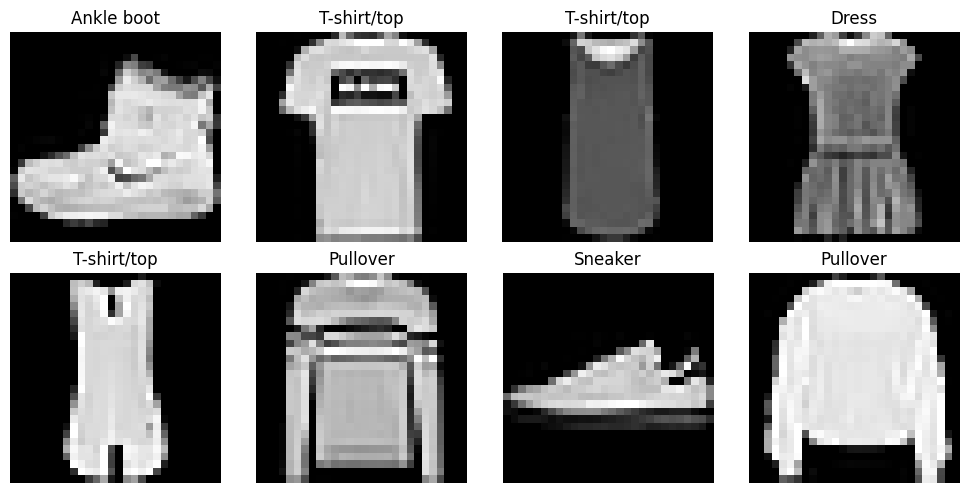

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from collections import Counter

#Loading the Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])#data transformation pipeline

#dividing the dataset into train e test set
trainset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

testset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

#Retrieving the class names from the dataset
class_names = trainset.classes
print("Classes:", class_names)

#Printing train and test set size divided per class
#Accessing the labels
train_labels = trainset.targets
test_labels = testset.targets

train_label_size = Counter(train_labels.tolist())
test_label_size = Counter(test_labels.tolist())

print("Train set size per class:")
for i, name in enumerate(class_names):
    print(f"{name}: {train_label_size[i]}")

print("Test set size per class:")
for i, name in enumerate(class_names):
    print(f"{name}: {test_label_size[i]}")

#Printing train and test set total size 
print("Total train set size:", len(trainset), "\n")
print("Total test set size:", len(testset), "\n")


#Restricting the classes
selected_classes = ["T-shirt/top", "Trouser", "Pullover", "Sneaker", "Bag", "Ankle boot"]
selected_idx = [class_names.index(c) for c in selected_classes] #Converting class names to class indices

#Filter train and test
train_filtered_idx = [i for i, label in enumerate(train_labels) if label in selected_idx]
test_filtered_idx = [i for i, label in enumerate(test_labels) if label in selected_idx]

train_subset = Subset(trainset, train_filtered_idx)
test_subset = Subset(testset, test_filtered_idx)

print(f"\nNumber of training instances after selection: {len(train_subset)}")
print(f"Number of testing instances after selection: {len(test_subset)}")

#Plotting example images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i in range(8):
    image, label = trainset[i]
    #undo normalization
    image = image * 0.5 + 0.5

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


**Answer:** TODO

## Part 2: Define a Dataset Class (8 Points)

Create a new Python file named `fmnist.py` in which you define the dataset class `FMNIST`, which inherits from `torch.utils.data.Dataset`:

- Your class should have the option to load the train or the test dataset from FashionMNIST.
- You should reduce the number of classes to the following six for training and testing (perform this step within the `__init__()` method): ["T-shirt/top", "Trouser", "Pullover", "Sneaker", "Bag", "Ankle Boot"]
- Apart from the required methods `__init__`, `__len__`, and `__getitem__`, introduce two property methods that let you access:
    - the private attribute `__train`, which indicates if the dataset is a training or test dataset of type `bool` (train should not be publicly accessible and modifiable), and
    - `label_dict`: a dictionary that maps the numerical labels [0, ..., 5] to the readable full text labels ["T-shirt/top", "Trouser", "Pullover", "Sneaker", "Bag", "Ankle Boot"].

**Hints:**

- Make sure to re-assign the labels of the selected classes to numbers in the range of [0,...,5]. Otherwise, this can lead to problems in the optimization.
- Assure that the `__getitem__` method applies the `Normalize` and `ToTensor` transformations from [Part 1](#part-1-exploring-the-dataset-4-points) before returning an image.

Test your implementation below by repeating the steps from Part 1 with your new dataset.

Train set size: 36000
Test set size: 6000
Train property: True
Test property: False
Label dict: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Sneaker', 4: 'Bag', 5: 'Ankle Boot'}
Training instances divided per class:
T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Sneaker: 6000
Bag: 6000
Ankle Boot: 6000

Testing instances divided per class:
T-shirt/top: 1000
Trouser: 1000
Pullover: 1000
Sneaker: 1000
Bag: 1000
Ankle Boot: 1000
Total training instances: 36000
Total testing instances: 6000


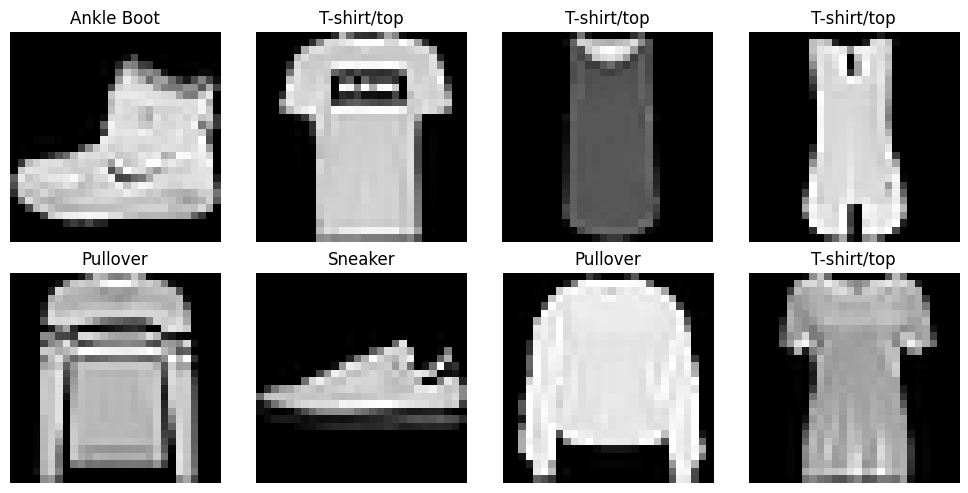

In [13]:
# Fill in your solution for testing your Dataset implementation here.
from fmnist import FMNIST
from collections import Counter
import matplotlib.pyplot as plt

trainset = FMNIST(train=True)
testset = FMNIST(train=False)

print("Train set size:", trainset.__len__())
print("Test set size:", testset.__len__())
print("Train property:", trainset.train)
print("Test property:", testset.train)
print("Label dict:", trainset.label_dict)

#Printing how many training and testing instances the dataset contains per class
train_counts = Counter(trainset._labels)
test_counts = Counter(testset._labels)

print("Training instances divided per class:")
for i, name in trainset.label_dict.items():
    print(f"{name}: {train_counts[i]}")

print("\nTesting instances divided per class:")
for i, name in testset.label_dict.items():
    print(f"{name}: {test_counts[i]}")

print("Total training instances:", len(trainset))
print("Total testing instances:", len(testset))


#Plotting example images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i in range(8):
    image, label = trainset[i]
    #undo normalization
    image = image * 0.5 + 0.5

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(trainset.label_dict[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()



## Part 3: Define a Neural Network (3 Points)

Create a new Python file named `networks.py` in which you define a neural network that is appropriate for the images from (FashionMNIST), which inherits from `torch.nn.module`.

To get full points, provide two different network architectures, a CNN and an MLP. Later you can run the experiments for both of them and compare the results.

**Hint**: Start with a simple and small network, e.g., the one we used for MNIST, and make sure that the dimensions and channels match your FMNIST dataset. Feel free to explore other networks later (see bonus points).

**<span style="color: red;">Minimum expectation for passing:</span>** A training loop needs to be completed with one model only.

## Part 4: Define a Lightning Module (6 Points)

Next, create a Python file named `networks_lightning.py` that defines your lightning module, which inherits from `pytorch_lightning.LightningModule`. The constructor should at least accept two named attributes:

- `model`, a `torch.nn.module` instance (e.g., the network(s) you defined in [Part 3](#part-3-define-a-neural-network-2-points)), and
- `lr`, a learning rate that can be provided by the user

For logging purposes, it might make sense to provide more hyperparameters here...

Besides that, implement the **necessary functions** to configure the optimizer and to perform training, validation and test steps. As a loss function, use the **cross entropy**, and for validation and testing, additionally **calculate and log the accuracy**.

## Part 5: Putting Everything Together (8 Points)

Complete the file `project_main.py` such that it has the following functionality:

- Train, validate and test your model on your new Dataset class `FMNIST` (create a test and validation split such that 80% of the training dataset is used for training and 20% for validation).
- Allow for early stopping based on the validation accuracy.
- The training (and validation) should be performed when the `--train` flag is passed, and the model should be tested when the `--evaluate` flag is passed to the script.
- When both `--train` and `--evaluate` are passed, use the model with the best validation accuracy (during the training) for testing.
- It should also be possible to only evaluate a model, for which the user provides the path to a checkpoint.
- Make sure that you log the hyperparameters including the model type (if you implemented more than one model)
- **Note that** if you implemented multiple models, make sure it is possible to select them with an appropriate flag. In addition, make sure that for evaluation, the provided model type matches the type of the model that generated the checkpoint.

After implementing the functionality, execute the following commands in this notebook and briefly summarize the results (use only one network here).

1. `%run project_main.py --train`
2. `%run project_main.py --evaluate --checkpoint <path to checkpoint from previous run>`
3. `%run project_main.py --train --evaluate`

Make sure that you select the number of epochs high enough such that the early stopping is triggered. Hint: use `Adam` or `AdamW` as an optimizer for faster convergence than with `SGD`. As a point of reference, I got an accuracy of around 96% (with a CNN) where early stopping was triggered after 15 epochs.

**<span style="color: red;">Minimum expectation for passing:</span>** Make sure that the network can train for at least 5 epochs (i.e., execute the first command with the flag `--epochs 5` or higher).

In [14]:
# Execute your runs below
#CNN example with default parameters
%run project_main.py --train --model cnn  --lr 0.0005 --epochs 20

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints exists and is not empty.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | CNN              | 206 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
206 K     Trainable params
0         Non-trainable params
206 K     Total params
0.826     Total estimated model params size (MB)
7     

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 14: 100%|██████████| 900/900 [00:08<00:00, 103.57it/s, v_num=_aug, val_loss=0.0894, val_acc=0.975, train_loss=0.020] 
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/cnn-epoch=09-val_acc=0.9771.ckpt


In [15]:
%run project_main.py --evaluate --checkpoint /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/cnn-epoch=09-val_acc=0.9771.ckpt

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 188/188 [00:00<00:00, 188.55it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9771666526794434
        test_loss           0.07342418283224106
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [16]:
#MLP example with default parameters
%run project_main.py --train --model mlp --epochs 20

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | MLP              | 109 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.437     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 10: 100%|██████████| 900/900 [00:08<00:00, 111.59it/s, v_num=_aug, val_loss=0.113, val_acc=0.966, train_loss=0.0515]
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/mlp-epoch=05-val_acc=0.9675.ckpt


In [17]:
%run project_main.py --evaluate --model mlp --checkpoint  /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/mlp-epoch=05-val_acc=0.9675.ckpt

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Testing DataLoader 0: 100%|██████████| 188/188 [00:00<00:00, 200.21it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9668333530426025
        test_loss           0.1041359230875969
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## Part 6: Adding Rotation (5 Points)

1. Add a random rotation of the image as a test time augmentation. 
    - In particular, for the test dataset randomly select a rotation angle in [0, 90, 180, 270] degrees before returning the image in the `__getitem__` function, and add an argument to the constructor which allows you to both create test datasets with this new feature, and create test datasets for which it is disabled (no rotation augmentation). The default the feature should be disabled, to be compatible with the previous code.
    - Add a functionality in `project_main.py` that allows you to activate these test-time augmentations with the flag `--rotate-test` and execute a full train/val and test routine with the flag activated, i.e., `%run project_main.py --train --evaluate --rotate-test`

    You should observe a significant drop in test performance to around 34% test accuracy.

2. Implement the same functionality for the training and validation dataset. The functionality should be activated by the flag `--rotate-train`, and be deactivated by default.
    - Test your implementation by running `%run project_main.py --train --evaluate --rotate-test --rotate-train`

    You should notice a significant improvement in test accuracy again. However, the performance will most likely be slightly worse than what you obtained in [Part 5](#part-5-putting-everything-together-8-points). As a reference, I got a test accuracy of around 92% with a CNN.

3. If you implemented more than one model, run Step 2 for two models and compare their results.

In [18]:
# Execute your runs below
#CNN training with rotation added to test and train
%run project_main.py --train --evaluate --rotate-test --rotate-train

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | CNN              | 206 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
206 K     Trainable params
0         Non-trainable params
206 K     Total params
0.826     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 19: 100%|██████████| 900/900 [00:09<00:00, 96.20it/s, v_num=_aug, val_loss=0.104, val_acc=0.968, train_loss=0.0538] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 900/900 [00:09<00:00, 96.17it/s, v_num=_aug, val_loss=0.104, val_acc=0.968, train_loss=0.0538]
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/cnn-epoch=17-val_acc=0.9679.ckpt
Testing DataLoader 0: 100%|██████████| 188/188 [00:01<00:00, 163.68it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9674999713897705
        test_loss           0.09444413334131241
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [19]:
#CNN training with rotation added ONLY to test
%run project_main.py --train --evaluate --rotate-test 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | CNN              | 206 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
206 K     Trainable params
0         Non-trainable params
206 K     Total params
0.826     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 15: 100%|██████████| 900/900 [00:09<00:00, 98.20it/s, v_num=_aug, val_loss=0.121, val_acc=0.975, train_loss=0.00943] 
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/cnn-epoch=10-val_acc=0.9776.ckpt
Testing DataLoader 0: 100%|██████████| 188/188 [00:01<00:00, 179.24it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.37716665863990784
        test_loss            8.097917556762695
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [20]:
#MLP training with rotation added to test and train
%run project_main.py --train --model mlp --evaluate --rotate-test --rotate-train

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints exists and is not empty.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | MLP              | 109 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.437     Total estimated model params size (MB)
6     

/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 900/900 [00:08<00:00, 107.07it/s, v_num=_aug, val_loss=0.147, val_acc=0.949, train_loss=0.110]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 900/900 [00:08<00:00, 107.03it/s, v_num=_aug, val_loss=0.147, val_acc=0.949, train_loss=0.110]
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/mlp-epoch=17-val_acc=0.9513.ckpt


/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 188/188 [00:00<00:00, 191.09it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9443333148956299
        test_loss           0.1561812460422516
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [21]:
#MLP training with rotation added ONLY to test
%run project_main.py --train --model mlp --evaluate --rotate-test 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | MLP              | 109 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.437     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 10: 100%|██████████| 900/900 [00:08<00:00, 105.70it/s, v_num=_aug, val_loss=0.113, val_acc=0.966, train_loss=0.0515]
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/mlp-epoch=05-val_acc=0.9675-v1.ckpt
Testing DataLoader 0: 100%|██████████| 188/188 [00:01<00:00, 176.14it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.3490000069141388
        test_loss            6.457447052001953
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## Part 7: Tensorboard Visualizations (6 Points)

Visualize the results from [Part 5](#part-5-putting-everything-together-8-points) and [Part 6](#part-6-adding-rotation-4-points) in Tensorboard (only the three distinct variants: without any augmentation, only with test augmentations, and with train and test augmentations). If you have more than one model, compare their results.

- Save the figures that visualize the train error, the validation accuracy, and the test accuracy in the `figures` folder,
- **show/visualize them in this notebook**, and 
- briefly discuss the differences (and similarities) that you observe between the three approaches.

Note: it is sufficient to download the images or make screenshots which you then embed into this document. Programmatic solutions are, however, also allowed.

**Answer:** TODO

In [29]:
#TODO
%load_ext tensorboard
%tensorboard --logdir model_checkpoints/cnn_logs
#To get the plots ->Scalars

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6009 (pid 15851), started 1:10:38 ago. (Use '!kill 15851' to kill it.)

In [30]:
#TODO
%load_ext tensorboard
%tensorboard --logdir model_checkpoints/mlp_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6010 (pid 16050), started 1:04:20 ago. (Use '!kill 16050' to kill it.)

<span style="color:red">DISCUSSION OF THE RESULTS OBTAINED</span>

<span style="font-weight: bold">CNN PLOTS</span>

![CNN Plots](figures/cnn_tensorboard_plots/all_cnn_plots.png)

The plots above combine all the plots for the three cnn models trained: the model trained with no augmentations in the dataset <span style="background-color: rgb(230, 125, 38)">(no_aug)</span> is displayed in orange, the model trained with augmentation only in the test set <span style="background-color: rgb(207, 54, 54)">(test_aug)</span> is displayed in red, and the model trained with augmentations in the train and test data <span style="background-color: rgb(71, 71, 234)">(train_test_aug)</span> is displayed in blue.

<span style="font-weight: bold">Training Loss</span> <br>
The no_augmentation and test_augmentation curves decrease faster and reach lower values compared to train_test_augmentation plot. 
This shows clearly that training without the augmentation allows the model to fit the data in a much quicker time and when the augmentation is applied during training the task results in a higher loss indicating that the model is having a harder time fitting the data.

<span style="font-weight: bold">Validation Loss</span> <br>
The train_test_augmentation plot starts with a higher loss value and decreases more slowly but it is more stable at the end, while the no_augmentation and test_augmentation curves achieve a lower validation loss earlier but have small fluctuations suggesting a slight overfitting issue.

<span style="font-weight: bold">Test Loss</span> <br>
The train_test_augmentation has a higher loss overall. 

<span style="font-weight: bold">Validation Accuracy</span> <br>
The no_augmentation and test_augmentation achieve the highest validation accuracy (around 0.975) while the train_test_augmentation is slightly lower (around 0.965). 

<span style="font-weight: bold">Test Accuracy</span> <br>
The no_augmentation and the train_test_augmentation have a very high accuracy (around 0.98) while the test_augmentation is very low (around 0.38) indicating that when augmentation is only applied at test time the performas drops significantly this happens because the trained model has never seen rotated instances and it causes a distribution shift on the data.


<span style="font-weight: bold">MLP PLOTS</span>

![MLP Plots](figures/mlp_tensorboard_plots/all_mlp_plots.png)

The plots above combine all the plots for the three cnn models trained: the model trained with no augmentations in the dataset <span style="background-color: rgb(230, 125, 38)">(no_aug)</span> is displayed in orange, the model trained with augmentation only in the test set <span style="background-color: rgb(207, 54, 54)">(test_aug)</span> is displayed in red, and the model trained with augmentations in the train and test data <span style="background-color: rgb(71, 71, 234)">(train_test_aug)</span> is displayed in blue. For some of the plots (train_loss, val_loss, val_acc) the test_aug is the same as the no_aug and for this reason it is not visible.

<span style="font-weight: bold">Training Loss</span> <br>
The no_augmentation and test_augmentation curves overlap, both decrase quickly and reach a lower training loss compared to the train_test_augmentation curve. This happens because augmentation is only applied at test time thus it is not influencing training.

<span style="font-weight: bold">Validation Loss</span> <br>
The no_augmentation and test_augmentation overlap againl they achieve a lower validation loss than the train_test_aumentation, this means that the MLP struggles more when it is trained with augmented data.

<span style="font-weight: bold">Test Loss</span> <br>
The train_test augmentation curve has slightly higher loss than no_augmentation while the test_augmentation curve performs poorly, this result it consistent with the low accuracy.

<span style="font-weight: bold">Validation Accuracy</span> <br>
The no_augmentation and test_augmentation overlap again in the graph and achieve the highest validation accuracy (around 0.965), while the train_test_augmentation is lower with a value around 0.94. 
Unlike the CNNs the MLP struggles with augmentation and does not benefit from it.

<span style="font-weight: bold">Test Accuracy</span> <br>
The no_augmentation and the train_test_augmentation have a very high test accuracy (around 0.97) while the test_augmentation has avery low accuracy (around 0.3), this means that applying augmentation only to the test set results in a significant drop in performance as seen also with the CNNs. The reason stays the same: the model has never seen rotated data causeing a distribution shift.


## Part 8: More Augmentations (3 Points)

Add at least one other **training-augmentation** (transformation), which can be activated by setting the flag `--use-augmentations` and evaluate it with the flag `--rotate-test` activated. 

- Execute the code below `%run ...`.
- Discuss your results. Does the performance increase or decrease? Why do you think this is the case?

In [1]:
# Exectue your code below
#CNN training with the new augmentations added to train set
%run project_main.py --train --evaluate --use-augmentations

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints exists and is not empty.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | CNN              | 206 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
206 K     Trainable params
0         Non-trainable params
206 K     Total params
0.826     Total estimated model params size (MB)
7     

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 14: 100%|██████████| 900/900 [00:08<00:00, 109.29it/s, v_num=art8, val_loss=0.0956, val_acc=0.973, train_loss=0.0271]
Best checkpoint: /Users/giulia/Documents/TU_Erasmus/AdvancedPython/AdvancedPython/final_project/model_checkpoints/cnn-epoch=09-val_acc=0.9764.ckpt


/Users/giulia/miniconda3/envs/mlenv2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 188/188 [00:00<00:00, 194.70it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9793333411216736
        test_loss           0.06851059943437576
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


<span style="color: red">**Answer:**</span> The performance in this case has a test_accuracy of 0.979 and a test loss of 0.068, for the CNN with rotations we had a test_accuracy of 0.96 and a test_loss of 0.09, while for the CNN with no rotations we had a test_accuracy of 0.97 and a test_loss of 0.07 because the additional augmentation introduces more variability during training allowing the model to learn more robust features. This improves generalization which is the main goal of machine learning allowing a better overall performance compared to using only rotations or no augmentation.

## Part 9 Analyzing the Error Source (3 Points)

Add another functionality (only for the test data). If you implemented two models, take the one with the lower test accuracy for this part. Run another evaluation with the model which consists of the following steps:

- Assess the balanced accuracy of the model and print it.
- Compute the accuracy per class, output it and plot the individual accuracies per class in a bar plot.
- Define a new flag that has to be set for executing this additional evaluation.

After implementing the steps above, execute a run of the variant below (`%run ..`). Use only the evaluation mode and provide a model checkpoint. Do not retrain the model.

Finally, visualize your plot below (it should show automatically) and discuss what you see. Does the method perform equally well for each class?

In [ ]:
# Exectue your code below

**Answer:** TODO

## Bonus (3 Points)

Explore different networks, optimizers, schedulers, early stopping criteria, or training augmentations to achieve a better test accuracy on the dataset variant that uses random test rotations (`--rotate-test`, see [Part 6](#part-6-adding-rotation-4-points)).

Make sure to set the seed `42` with the `set_seed` method before testing the model.

Here you will earn half a bonus point for every margin of 0.5% that you improve over an accuracy of 93.00% (at most 3 points). That is, if you get a test accuracy $> 93.50$%, you get half a point, with an accuracy $> 94.00$% a full point, ...

**To earn the bonus points, execute the run with your best configuration below. Again note: You need to use rotations for the test data and seed 42.**

In [1]:
# Execute your code with the new setting (parametrized by flags) below.